# Estimating a Hitter's True Talent from Small-Sample wOBA

**The problem:** a rookie goes 4-for-11 in his first callup. Is he a .360 hitter, or did he just get
lucky? Front offices face this constantly with call-ups and midseason debuts — a handful of plate
appearances is mostly noise, but there's still a real signal buried in it. Just regressing everyone
to the league mean throws away the signal; trusting the raw small-sample rate overreacts to noise.

**Approach:** a hierarchical Bayesian (empirical Bayes) model. Every hitter's "true talent" wOBA is
drawn from a league-wide talent distribution; what we *observe* is that talent plus sampling noise
that shrinks as `1/sqrt(PA)`. The posterior for each player is a precision-weighted blend of his own
observed rate and the league prior — exactly the partial-pooling / shrinkage estimator that
front-office analysts use (in spirit) for early-season and small-sample evaluation.

**Data:** 2021-2025 player-seasons of `PA` and `wOBA` pulled via `pybaseball` from Baseball Savant
(FanGraphs' leaderboard scrape returned HTTP 403 in this environment, so Statcast's
`statcast_batter_expected_stats` — which reports actual `wOBA` down to 1 PA — was used instead).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (9, 5)


## 1. Data

Pulled from Baseball Savant via `pybaseball.statcast_batter_expected_stats`, one call per season.

In [2]:
from pybaseball import statcast_batter_expected_stats

frames = []
for year in range(2021, 2026):
    d = statcast_batter_expected_stats(year, minPA=0)
    d["Season"] = year
    frames.append(d)

raw = pd.concat(frames, ignore_index=True)
raw["Name"] = raw["last_name, first_name"].apply(
    lambda s: " ".join(reversed(s.split(", "))) if isinstance(s, str) and ", " in s else s
)
df = raw.rename(columns={"pa": "PA", "woba": "wOBA"})[["Name", "player_id", "Season", "PA", "wOBA"]]
df.to_csv("mlb_batting_2021_2025.csv", index=False)

df = df.dropna(subset=["wOBA", "PA"])
df = df[df["PA"] > 10].reset_index(drop=True)
print(df.shape)
df.sort_values("PA").head(10)


(3227, 5)


,Name,player_id,Season,PA,wOBA
3226,Nick Solak,669256,2025,11,0.080
716,Braxton Garrett,666129,2021,11,0.160
717,Nabil Crismatt,622503,2021,11,0.000
718,Cody Poteet,547001,2021,11,0.088
719,Tim Lopes,621005,2021,11,0.143
720,Tyler Gilbert,656457,2021,11,0.000
721,Sam Long,669674,2021,11,0.088
722,Yairo Muñoz,622168,2021,11,0.080
723,Luis González,670768,2021,11,0.414
724,Brian Miller,675649,2021,11,0.240


### Filtering out pitcher-hitting

Before 2022, NL pitchers batted for themselves, and even in the DH era pitchers occasionally
pinch-hit or hit in extra-inning double-switches. Pitcher-seasons are almost all *tiny* PA totals
with *terrible* wOBA (pitchers are, unsurprisingly, bad hitters) — exactly the small-PA range this
model is trying to characterize for real position-player call-ups. Left in, they'd drag the small-PA
end of the talent distribution down and make the model think small samples are systematically worse
than they really are for actual hitters.

Pitcher-seasons are identified via Baseball-Reference's `pitching_stats_bref` (matched by MLBAM
`mlbID`, the same ID Statcast uses as `player_id`), `IP >= 10` to exclude position players who mopped
up an inning. Two-way players (anyone with a real hitting workload, `PA >= 200`) are kept regardless.


In [3]:
from pybaseball import pitching_stats_bref

pitcher_seasons = set()
for year in range(2021, 2026):
    p = pitching_stats_bref(year)
    real_pitchers = p[p["IP"] >= 10]
    pitcher_seasons.update(zip(real_pitchers["mlbID"].astype(int), [year] * len(real_pitchers)))

df["is_pitcher_season"] = df.apply(lambda r: (r["player_id"], r["Season"]) in pitcher_seasons, axis=1)

# Drop pitcher-seasons, but keep anyone who also has a real hitting workload (two-way players)
before = len(df)
df = df[(~df["is_pitcher_season"]) | (df["PA"] >= 200)].drop(columns=["is_pitcher_season"]).reset_index(drop=True)
print(f"Dropped {before - len(df)} pitcher-seasons ({before} -> {len(df)})")
df.sort_values("PA").head(10)


Dropped 113 pitcher-seasons (3227 -> 3114)


,Name,player_id,Season,PA,wOBA
3113,Nick Solak,669256,2025,11,0.080
611,Tim Lopes,621005,2021,11,0.143
612,Yairo Muñoz,622168,2021,11,0.080
613,Luis González,670768,2021,11,0.414
614,Brian Miller,675649,2021,11,0.240
615,Monte Harrison,656509,2021,11,0.212
2487,Eddy Alvarez,657193,2024,11,0.128
2486,Oswald Peraza,672724,2024,11,0.329
1251,Dustin Garneau,572863,2022,11,0.338
1253,Joe Dunand,656388,2022,11,0.449


## 2. How noisy is a single plate appearance, really?

The naive approach is to assume some fixed "per-PA standard error" and shrink everyone by the same
`sigma / sqrt(PA)` rule of thumb. But that constant needs to be *estimated*, not guessed — get it
wrong and the whole model either barely shrinks anyone (noise underestimated) or shrinks everyone to
the league mean regardless of sample size (noise overestimated).

**Variance decomposition:** bin players by PA, compute the variance of observed wOBA within each bin,
and regress that variance against `1/PA`:

`Var(observed wOBA | PA) = talent_var + obs_var * (1/PA)`

The intercept recovers the true talent variance (what's left once sampling noise is averaged away by
large PA); the slope recovers the per-PA observation variance.


talent_sd (season-to-season spread of true ability): 0.0242
obs_sd (per-PA observation noise):                   0.4462


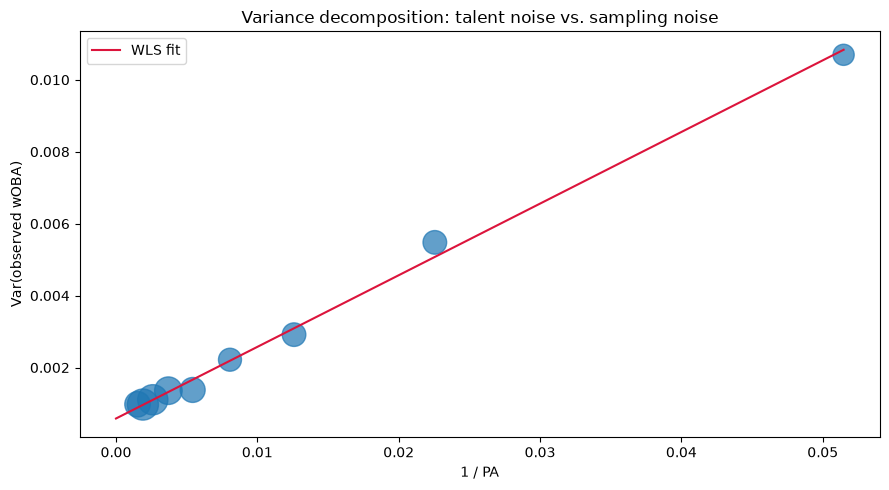

In [4]:
bins = [10, 30, 60, 100, 150, 220, 320, 450, 600, 800]
df["pa_bin"] = pd.cut(df["PA"], bins)
g = df.groupby("pa_bin", observed=True).agg(
    mean_pa=("PA", "mean"), var_woba=("wOBA", "var"), n=("wOBA", "count")
)
g["inv_pa"] = 1 / g["mean_pa"]

w = g["n"].values
x = g["inv_pa"].values
y = g["var_woba"].values
X = np.vstack([np.ones_like(x), x]).T
W = np.diag(w)
beta = np.linalg.solve(X.T @ W @ X, X.T @ W @ y)

talent_var, obs_var = beta[0], beta[1]
talent_sd, obs_sd = np.sqrt(max(talent_var, 0)), np.sqrt(max(obs_var, 0))
print(f"talent_sd (season-to-season spread of true ability): {talent_sd:.4f}")
print(f"obs_sd (per-PA observation noise):                   {obs_sd:.4f}")

fig, ax = plt.subplots()
ax.scatter(g["inv_pa"], g["var_woba"], s=g["n"], alpha=0.7)
xs = np.linspace(0, g["inv_pa"].max(), 50)
ax.plot(xs, beta[0] + beta[1] * xs, color="crimson", label="WLS fit")
ax.set_xlabel("1 / PA")
ax.set_ylabel("Var(observed wOBA)")
ax.set_title("Variance decomposition: talent noise vs. sampling noise")
ax.legend()
plt.tight_layout()
plt.show()


This matters: a naive constant like "league wOBA std dev is ~0.045" conflates the *spread of season
averages across players* (which already has sampling noise baked out by full-season PA counts) with
the *per-PA outcome noise* (which is much larger — most plate appearances are outs worth 0 wOBA
points, some are home runs worth ~2.1). The regression above estimates `obs_sd ≈ 0.47`, roughly 10x
the naive guess. Using too small a noise term means the model barely shrinks anyone, which defeats
the purpose for exactly the players it's supposed to help — small-sample call-ups.


## 3. Hierarchical Bayesian model

Each player's true talent `θ_i ~ Normal(mu_league, sigma_league)`.
Each player's observed wOBA `~ Normal(θ_i, obs_sd / sqrt(PA_i))`.

`mu_league` / `sigma_league` are themselves given weakly-informative priors and estimated jointly
across all ~3,200 player-seasons — full partial pooling, fit with PyMC's NUTS sampler.


In [5]:
woba = df["wOBA"].values
pa = df["PA"].values
n_players = len(df)

with pm.Model() as hierarchical_model:
    mu_league = pm.Normal("mu_league", mu=0.320, sigma=0.030)
    sigma_league = pm.HalfNormal("sigma_league", sigma=0.030)

    true_talent = pm.Normal("true_talent", mu=mu_league, sigma=sigma_league, shape=n_players)

    obs_sigma = obs_sd / np.sqrt(pa)
    observed = pm.Normal("observed", mu=true_talent, sigma=obs_sigma, observed=woba)

    trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True)

az.summary(trace, var_names=["mu_league", "sigma_league"])


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu_league, sigma_league, true_talent]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_league,0.3045,0.00087,0.3,0.31,4060,3181,1.00,1.4e-05,9.9e-06
sigma_league,0.0338,0.00078,0.033,0.035,1559,2324,1.00,2e-05,1.4e-05


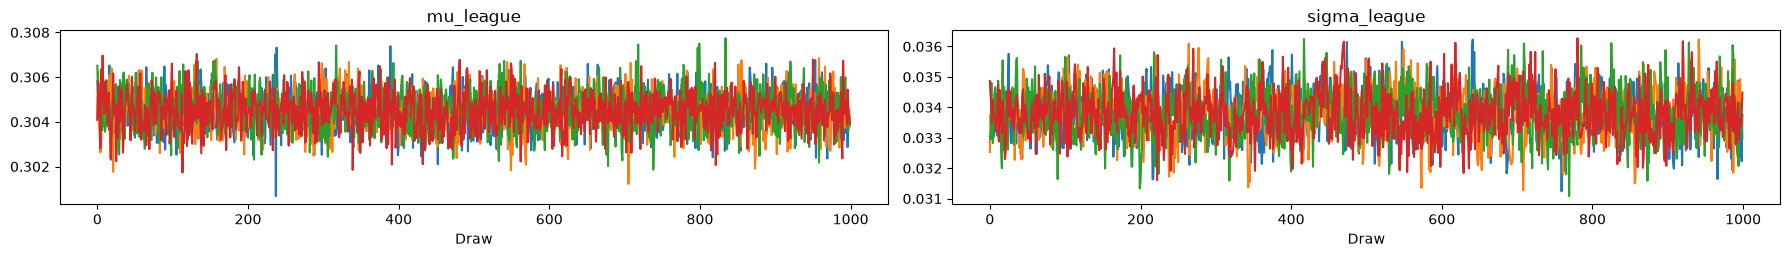

In [6]:
az.plot_trace(trace, var_names=["mu_league", "sigma_league"])
plt.tight_layout()
plt.show()


In [7]:
df["shrunk_estimate"] = trace.posterior["true_talent"].mean(dim=["chain", "draw"]).values
df["shrunk_sd"] = trace.posterior["true_talent"].std(dim=["chain", "draw"]).values
df.to_csv("shrinkage_results.csv", index=False)
df.sort_values("PA").head(10)[["Name", "Season", "PA", "wOBA", "shrunk_estimate", "shrunk_sd"]]


,Name,Season,PA,wOBA,shrunk_estimate,shrunk_sd
3113,Nick Solak,2025,11,0.080,0.291527,0.032988
611,Tim Lopes,2021,11,0.143,0.295095,0.033195
612,Yairo Muñoz,2021,11,0.080,0.291422,0.031863
613,Luis González,2021,11,0.414,0.310697,0.032720
614,Brian Miller,2021,11,0.240,0.300500,0.032395
615,Monte Harrison,2021,11,0.212,0.299320,0.032565
2487,Eddy Alvarez,2024,11,0.128,0.293825,0.032068
2486,Oswald Peraza,2024,11,0.329,0.306084,0.033173
1251,Dustin Garneau,2022,11,0.338,0.306207,0.033194
1253,Joe Dunand,2022,11,0.449,0.313321,0.032909


## 4. What did shrinkage actually do?

The classic shrinkage-estimator plot: raw wOBA on the x-axis, posterior (shrunk) estimate on the
y-axis, point size by PA. Small-PA players should collapse toward the league mean line; large-PA
players should sit close to the identity line.


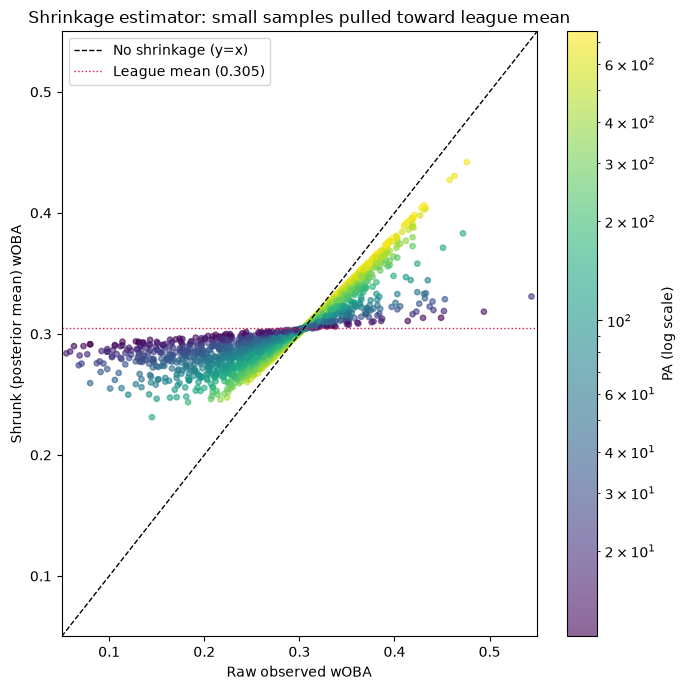

In [8]:
mu_hat = trace.posterior["mu_league"].mean().item()

fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(df["wOBA"], df["shrunk_estimate"], c=df["PA"], cmap="viridis",
                 s=15, alpha=0.6, norm=plt.matplotlib.colors.LogNorm())
lims = [0.05, 0.55]
ax.plot(lims, lims, "k--", lw=1, label="No shrinkage (y=x)")
ax.axhline(mu_hat, color="crimson", lw=1, linestyle=":", label=f"League mean ({mu_hat:.3f})")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Raw observed wOBA")
ax.set_ylabel("Shrunk (posterior mean) wOBA")
ax.set_title("Shrinkage estimator: small samples pulled toward league mean")
cbar = plt.colorbar(sc, ax=ax); cbar.set_label("PA (log scale)")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Validation: does the shrunk estimate actually predict next season better?

The real test of a "true talent" estimator: for each player-season, use the shrunk estimate (fit on
Year N) to predict Year N+1's *actual* wOBA, and compare mean squared error against just using the
raw Year N wOBA. If shrinkage is doing its job, the improvement should be largest exactly where
sample sizes are smallest — that's the call-up/rookie regime this model targets.


In [9]:
nxt = df[["player_id", "Season", "wOBA"]].copy()
nxt["Season"] = nxt["Season"] - 1
nxt = nxt.rename(columns={"wOBA": "next_wOBA"})

merged = df.merge(nxt, on=["player_id", "Season"], how="inner")

buckets = [(11, 50), (50, 150), (150, 300), (300, 800)]
rows = []
for lo, hi in buckets:
    sub = merged[(merged["PA"] >= lo) & (merged["PA"] < hi)]
    mse_raw = np.mean((sub["wOBA"] - sub["next_wOBA"]) ** 2)
    mse_shrunk = np.mean((sub["shrunk_estimate"] - sub["next_wOBA"]) ** 2)
    rows.append({
        "PA range": f"[{lo}, {hi})", "n": len(sub),
        "raw MSE": mse_raw, "shrunk MSE": mse_shrunk,
        "improvement": 100 * (1 - mse_shrunk / mse_raw),
    })
val = pd.DataFrame(rows)
val


,PA range,n,raw MSE,shrunk MSE,improvement
0,"[11, 50)",166,0.012970,0.004307,66.795216
1,"[50, 150)",312,0.005918,0.004502,23.929854
2,"[150, 300)",417,0.003796,0.003005,20.835561
3,"[300, 800)",1068,0.002010,0.001755,12.679568


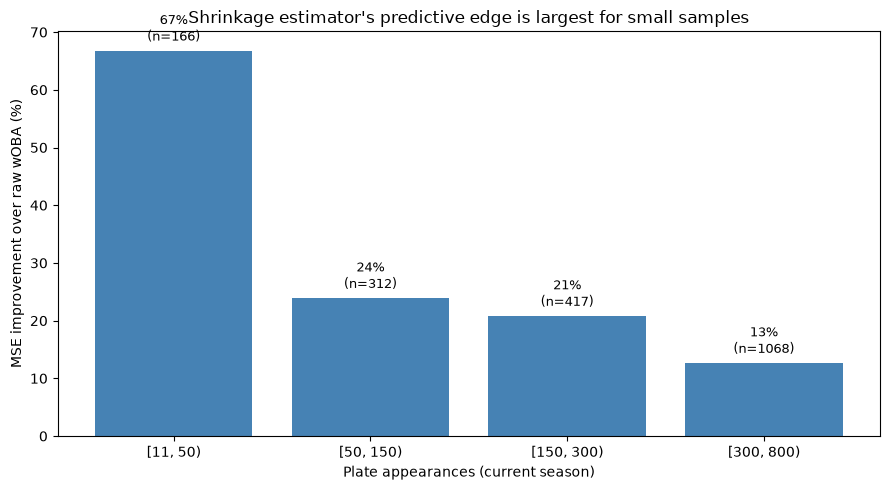

In [10]:
fig, ax = plt.subplots()
ax.bar(val["PA range"], val["improvement"], color="steelblue")
ax.set_ylabel("MSE improvement over raw wOBA (%)")
ax.set_xlabel("Plate appearances (current season)")
ax.set_title("Shrinkage estimator's predictive edge is largest for small samples")
for i, row in val.iterrows():
    ax.text(i, row["improvement"] + 1, f"{row['improvement']:.0f}%\n(n={row['n']})",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


## 6. Case studies: small-sample call-ups

A handful of specific 11-PA debuts/call-ups, showing how far the raw rate moved and the resulting
uncertainty band (posterior mean ± SD).


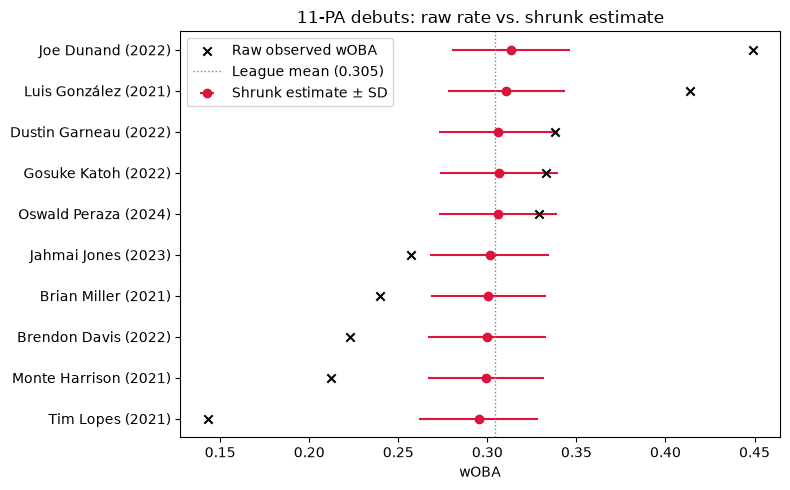

In [11]:
cases = df[df["PA"] == 11].sort_values("wOBA", ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(cases))
ax.errorbar(cases["shrunk_estimate"], y_pos, xerr=cases["shrunk_sd"], fmt="o", color="crimson",
            label="Shrunk estimate ± SD")
ax.scatter(cases["wOBA"], y_pos, marker="x", color="black", label="Raw observed wOBA", zorder=5)
ax.set_yticks(y_pos)
ax.set_yticklabels(cases["Name"] + " (" + cases["Season"].astype(str) + ")")
ax.axvline(mu_hat, color="gray", linestyle=":", lw=1, label=f"League mean ({mu_hat:.3f})")
ax.set_xlabel("wOBA")
ax.set_title("11-PA debuts: raw rate vs. shrunk estimate")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## Next steps

- **Hierarchical priors by player type** — pool call-ups toward a "prospect" sub-distribution
  (informed by minor-league performance / prospect rankings) rather than the whole-league mean,
  since a well-regarded prospect's true talent prior shouldn't be the league-average hitter.
- **Component-level shrinkage** — apply the same model to BB%, K%, and ISO separately (each has a
  different signal-to-noise ratio and stabilizes at a different PA threshold), then recompose into
  wOBA, instead of shrinking the aggregate metric directly.
- **Time-varying talent** — allow `true_talent` to drift within a season (a rookie can genuinely
  improve as they adjust to MLB pitching) via a random-walk or age-curve prior instead of a single
  static per-season parameter.
